# Trigonometric Functions — Lecture 4
## Allied Angles in Practice · Negative Angles · Expansion Formulae

**Source:** [Trigonometric Functions 04 | Expansion Formulae](https://www.youtube.com/watch?v=Ynr3x0Sk2h0&list=PLF_7kfnwLFCGWE2w0BsarSM9mbBJMrdRL&index=4), Physics Wallah (Class 11 / IIT JEE, PACE series), about 54 min

**Prerequisite:** Lecture 3 (sign scheme, trig table, the two rules for allied angles).

### What this lecture covers
1. Which angles lie on which axis: $n\pi$ on the x-axis, $(2n+1)\frac{\pi}{2}$ on the y-axis
2. Lecture 3 homework, plus more allied-angle simplifications ($\sin(8\pi-\theta)$, $\tan(\frac{11\pi}{2}+\theta)$, …)
3. Values at large angles: $\sin 180^\circ$, $\cos 210^\circ$, $\sec 330^\circ$, $\tan 870^\circ$
4. **Negative angles:** $\sin(-\theta) = -\sin\theta$ but $\cos(-\theta) = \cos\theta$
5. **Expansion formulae** for $\sin(A\pm B)$, $\cos(A\pm B)$, $\tan(A\pm B)$, $\cot(A\pm B)$
6. Solved questions: $\sin 75^\circ$, and $\sin(A-B)$ given $\sin A$ and $\cos B$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, FancyArrowPatch, Polygon, Rectangle

# Same look as the earlier lectures
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
POS_BG, NEG_BG = "#2a78d61a", "#eb68341a"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def clean(ax, lim=1.4):
    ax.set_aspect("equal"); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.axis("off")

def axes_cross(ax, lim=1.3):
    for xy in [((-lim, 0), (lim, 0)), ((0, -lim), (0, lim))]:
        ax.annotate("", xy=xy[1], xytext=xy[0], arrowprops=dict(arrowstyle="-|>", color=INK2, lw=1))
    ax.text(lim, -0.08, "x", ha="right", va="top", color=INK2); ax.text(0.05, lim, "y", va="top", color=INK2)

def sweep(ax, start_deg, end_deg, r0=0.3, color=BLUE, turns_gap=0.0):
    t = np.linspace(np.deg2rad(start_deg), np.deg2rad(end_deg), 600)
    rr = r0 + turns_gap*np.abs(t - t[0])/(2*np.pi)
    ax.plot(rr*np.cos(t), rr*np.sin(t), color=color, lw=1.6)
    ax.add_patch(FancyArrowPatch((rr[-6]*np.cos(t[-6]), rr[-6]*np.sin(t[-6])),
                                 (rr[-1]*np.cos(t[-1]), rr[-1]*np.sin(t[-1])),
                                 arrowstyle="-|>", mutation_scale=12, color=color, lw=0))

# The two rules from Lecture 3, as code
F = {"sin": np.sin, "cos": np.cos, "tan": np.tan, "cot": lambda t: 1/np.tan(t),
     "sec": lambda t: 1/np.cos(t), "cosec": lambda t: 1/np.sin(t)}
CO = {"sin": "cos", "cos": "sin", "tan": "cot", "cot": "tan", "sec": "cosec", "cosec": "sec"}
POSITIVE_IN = {1: set(F), 2: {"sin", "cosec"}, 3: {"tan", "cot"}, 4: {"cos", "sec"}}

def allied(fname, k, sign):
    # Simplify f(k·π/2 + sign·θ), θ acute  →  (sign, function, quadrant)
    q = int(((k*90 + sign*30) % 360) // 90) + 1     # use θ = 30° to locate the quadrant
    s = "+" if fname in POSITIVE_IN[q] else "−"      # Rule 1: sign of the ORIGINAL function in that quadrant
    g = fname if k % 2 == 0 else CO[fname]           # Rule 2: x-axis keeps, y-axis swaps
    return s, g, q
print("ready")

ready


---
## 1. Which Angles Lie on Which Axis?

Start with the initial line along the positive x-axis and keep rotating.

**On the x-axis: integer multiples of $\pi$ ($n\pi$)**
- **Even** multiples $0, \pm 2\pi, \pm 4\pi, \dots$ end on the **positive** x-axis, back on the initial line.
- **Odd** multiples $\pm\pi, \pm 3\pi, \pm 5\pi, \dots$ end on the **negative** x-axis.

**On the y-axis: odd multiples of $\frac{\pi}{2}$, i.e. $(2n+1)\frac{\pi}{2}$**
- **Positive y-axis:** $\frac{\pi}{2}, \frac{5\pi}{2}, \frac{9\pi}{2}, \dots$ and $-\frac{3\pi}{2}, -\frac{7\pi}{2}, \dots$. The positive numerators are one **more** than a multiple of 4.
- **Negative y-axis:** $\frac{3\pi}{2}, \frac{7\pi}{2}, \frac{11\pi}{2}, \dots$ and $-\frac{\pi}{2}, -\frac{5\pi}{2}, \dots$. The positive numerators are one **less** than a multiple of 4.

Combine this with the quadrant sign scheme and you can simplify **any** $f(\text{axis angle} \pm \theta)$ using the two rules from Lecture 3:

| Step | Question | Decides |
|---|---|---|
| Rule 1 | Which **quadrant** is the whole angle in? | The sign ($+$ or $-$) |
| Rule 2 | Is the axis angle on the **x-axis** or the **y-axis**? | Whether the function stays the same (x) or swaps to its co-function (y) |

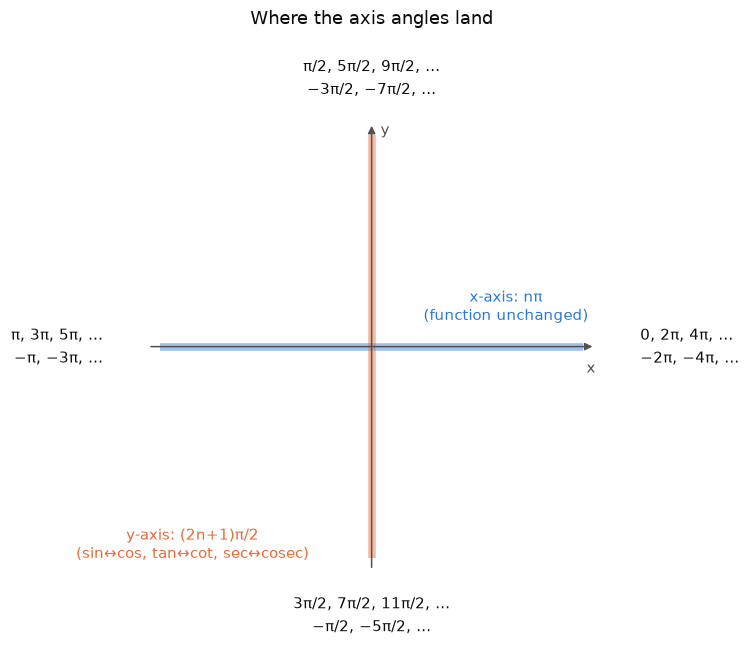

In [2]:
fig, ax = plt.subplots(figsize=(7.4, 7.4)); clean(ax, 1.75)
axes_cross(ax, 1.25)
groups = [
    (0,   "0, 2π, 4π, …\n−2π, −4π, …", BLUE,   (1.5, 0.0), "left"),
    (180, "π, 3π, 5π, …\n−π, −3π, …",  BLUE,   (-1.5, 0.0), "right"),
    (90,  "π/2, 5π/2, 9π/2, …\n−3π/2, −7π/2, …", ORANGE, (0.0, 1.5), "center"),
    (270, "3π/2, 7π/2, 11π/2, …\n−π/2, −5π/2, …", ORANGE, (0.0, -1.5), "center"),
]
for deg, lab, col, (tx, ty), ha in groups:
    r = np.deg2rad(deg)
    ax.plot([0, 1.18*np.cos(r)], [0, 1.18*np.sin(r)], color=col, lw=5, alpha=0.45, solid_capstyle="butt")
    ax.text(tx if ha != "center" else 0, ty, lab, ha=ha if ha != "center" else "center",
            va="center", fontsize=10, color=INK, linespacing=1.5)
ax.text(0.75, 0.12, "x-axis: nπ\n(function unchanged)", color=BLUE, fontsize=10, ha="center", va="bottom")
ax.text(-1.0, -1.18, "y-axis: (2n+1)π/2\n(sin↔cos, tan↔cot, sec↔cosec)", color=ORANGE, fontsize=10, ha="center")
ax.set_title("Where the axis angles land", fontsize=12)
plt.show()

---
## 2. Allied Angles in Practice

### 2.1 Lecture 3 homework
**(a) $\sin(4\pi - \theta)$**
- $4\pi$ is an even multiple of $\pi$, so it is on the positive x-axis. Going back by $\theta$ lands in **quadrant IV**, where $\sin < 0$.
- Since $4\pi$ is on the **x-axis**, $\sin$ stays $\sin$.

$$\sin(4\pi - \theta) = -\sin\theta$$

**(b) $\cos\left(\frac{3\pi}{2} + \theta\right)$**
- $\frac{3\pi}{2}$ is on the negative y-axis. Going forward by $\theta$ lands in **quadrant IV**, where $\cos > 0$.
- Since $\frac{3\pi}{2}$ is on the **y-axis**, $\cos$ becomes $\sin$.

$$\cos\left(\tfrac{3\pi}{2} + \theta\right) = \sin\theta$$

### 2.2 More examples from the lecture

| Expression | Quadrant | Sign there | Axis | Result |
|---|---|---|---|---|
| $\sin(8\pi - \theta)$ | IV | $\sin$: $-$ | x | $-\sin\theta$ |
| $\tan\left(\frac{11\pi}{2} + \theta\right)$ | IV | $\tan$: $-$ | y | $-\cot\theta$ |
| $\cot\left(\frac{11\pi}{2} - \theta\right)$ | III | $\cot$: $+$ | y | $\tan\theta$ |

($\frac{11\pi}{2}$ is one less than $12 = 3 \times 4$ in the numerator, so it lies on the **negative y-axis**.)

**Always check the sign of the original function**, not of the function it turns into.

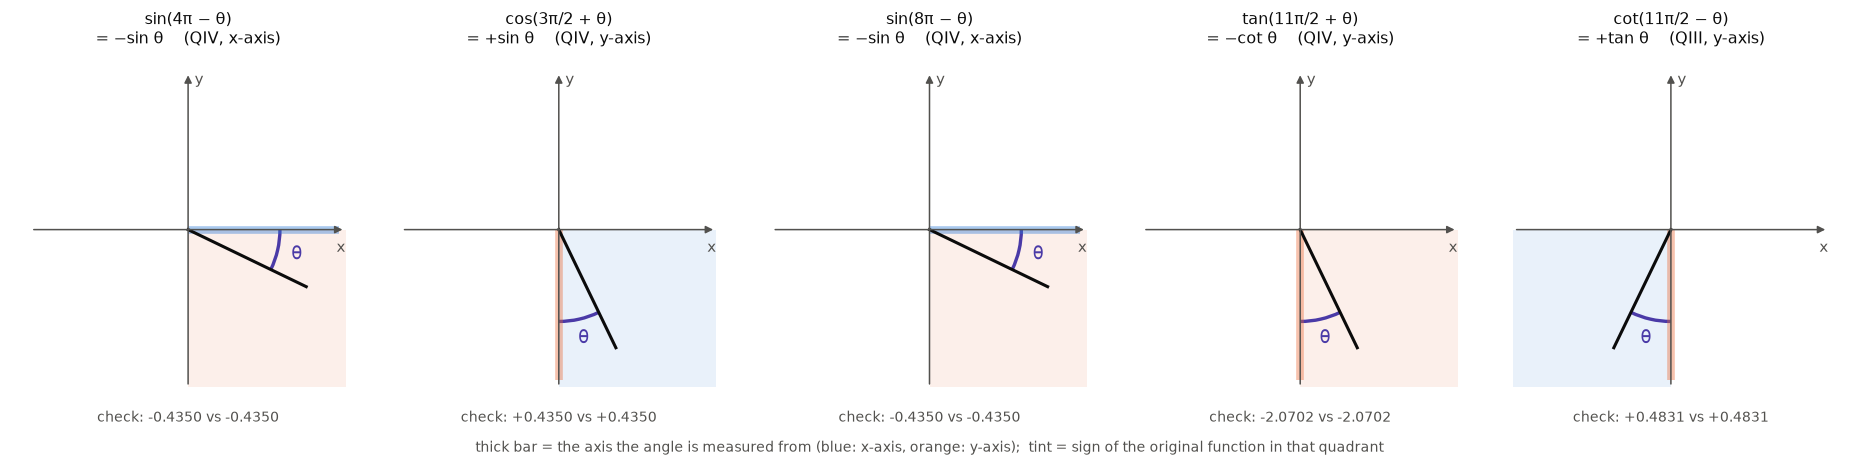

In [3]:
examples = [("sin", 8, -1, "sin(4π − θ)"), ("cos", 3, 1, "cos(3π/2 + θ)"),
            ("sin", 16, -1, "sin(8π − θ)"), ("tan", 11, 1, "tan(11π/2 + θ)"), ("cot", 11, -1, "cot(11π/2 − θ)")]
fig, axes = plt.subplots(1, 5, figsize=(17, 3.9))
theta = 0.45
for ax, (fname, k, sign, label) in zip(axes, examples):
    clean(ax, 1.35); axes_cross(ax, 1.2)
    s, g, q = allied(fname, k, sign)
    base = (k*90) % 360; end = base + sign*np.rad2deg(theta)
    ax.add_patch(Rectangle(((0 if q in (1, 4) else -1.2), (0 if q in (1, 2) else -1.2)), 1.2, 1.2,
                           fc=POS_BG if s == "+" else NEG_BG, ec="none"))
    axis_col = BLUE if k % 2 == 0 else ORANGE
    rb = np.deg2rad(base)
    ax.plot([0, 1.15*np.cos(rb)], [0, 1.15*np.sin(rb)], color=axis_col, lw=5, alpha=0.4, solid_capstyle="butt")
    re = np.deg2rad(end)
    ax.plot([0, np.cos(re)], [0, np.sin(re)], color=INK, lw=2)
    ax.add_patch(Arc((0, 0), 1.4, 1.4, theta1=min(base, end), theta2=max(base, end), color=VIOLET, lw=2.2))
    ax.text(0.85*np.cos(np.deg2rad((base + end)/2)), 0.85*np.sin(np.deg2rad((base + end)/2)), "θ",
            color=VIOLET, fontsize=12, ha="center", va="center")
    ax.set_title(f"{label}\n= {s}{g} θ    (Q{['I','II','III','IV'][q-1]}, {'x' if k % 2 == 0 else 'y'}-axis)", fontsize=10.5)
    actual = F[fname](k*np.pi/2 + sign*theta); pred = (1 if s == "+" else -1)*F[g](theta)
    ax.text(0, -1.38, f"check: {actual:+.4f} vs {pred:+.4f}", ha="center", va="top", fontsize=9, color=INK2)
fig.text(0.5, -0.02, "thick bar = the axis the angle is measured from (blue: x-axis, orange: y-axis);  "
         "tint = sign of the original function in that quadrant", ha="center", color=INK2, fontsize=9)
plt.tight_layout(); plt.show()

### 2.3 Values at large angles
**Strategy:** split the angle as (axis angle) $\pm$ (standard angle from the table), then apply the two rules.

| Angle | Split | Quadrant | Rules | Value |
|---|---|---|---|---|
| $\sin 180^\circ$ | $180^\circ + 0^\circ$ | on the axis | x-axis: $\sin$ stays | $\sin 0^\circ = 0$ |
| $\cos 210^\circ$ | $180^\circ + 30^\circ$ | III, $\cos < 0$ | x-axis: $\cos$ stays | $-\cos 30^\circ = -\dfrac{\sqrt3}{2}$ |
| $\sec 330^\circ$ | $360^\circ - 30^\circ$ | IV, $\sec > 0$ | x-axis: $\sec$ stays | $\sec 30^\circ = \dfrac{2}{\sqrt3}$ |
| $\tan 870^\circ$ | $900^\circ - 30^\circ = 5\times 180^\circ - 30^\circ$ | II, $\tan < 0$ | x-axis: $\tan$ stays | $-\tan 30^\circ = -\dfrac{1}{\sqrt3}$ |

$900^\circ = 5 \times 180^\circ$ is an odd multiple of $\pi$, so it lies on the **negative x-axis**. Coming back by $30^\circ$ puts the angle in quadrant II.

> **Homework from the lecture:** evaluate $\cot$ of a large angle and post the value in the comments. The exact angle is unclear in the auto-captions, so try $\cot 1470^\circ$ as a stand-in. The answer is in the cell below.

In [4]:
def show(name, deg, exact):
    v = F[name](np.deg2rad(deg))
    print(f"{name:>5}({deg:>5}°) = {v:+.6f}    exact {exact:<8} = {eval(exact.replace('√', 'np.sqrt')):+.6f}")

show("sin", 180, "0")
show("cos", 210, "-√(3)/2")
show("sec", 330, "2/√(3)")
show("tan", 870, "-1/√(3)")
show("cot", 1470, "√(3)")        # 1470° = 8·180° + 30° → QI, x-axis → cot 30°

  sin(  180°) = +0.000000    exact 0        = +0.000000
  cos(  210°) = -0.866025    exact -√(3)/2  = -0.866025
  sec(  330°) = +1.154701    exact 2/√(3)   = +1.154701
  tan(  870°) = -0.577350    exact -1/√(3)  = -0.577350
  cot( 1470°) = +1.732051    exact √(3)     = +1.732051


---
## 3. Negative Angles

$$\sin(-\theta) = -\sin\theta, \quad \tan(-\theta) = -\tan\theta, \quad \cot(-\theta) = -\cot\theta, \quad \csc(-\theta) = -\csc\theta$$
$$\cos(-\theta) = \cos\theta, \qquad \sec(-\theta) = \sec\theta$$

**In words:** $\sin, \tan, \cot$ and $\csc$ let you **pull the minus sign outside**. $\cos$ and $\sec$ are the "soft" functions that **swallow** the minus sign.

**Why (using the two rules):** $-\theta = 0 - \theta$.
- $0$ is on the **x-axis**, so no function changes.
- $-\theta$ (clockwise from $0$) lies in **quadrant IV**, where **only $\cos$ and $\sec$ are positive**. Every other function picks up a minus sign.

(In later chapters: $\cos$ and $\sec$ are **even** functions, and the other four are **odd** functions.)

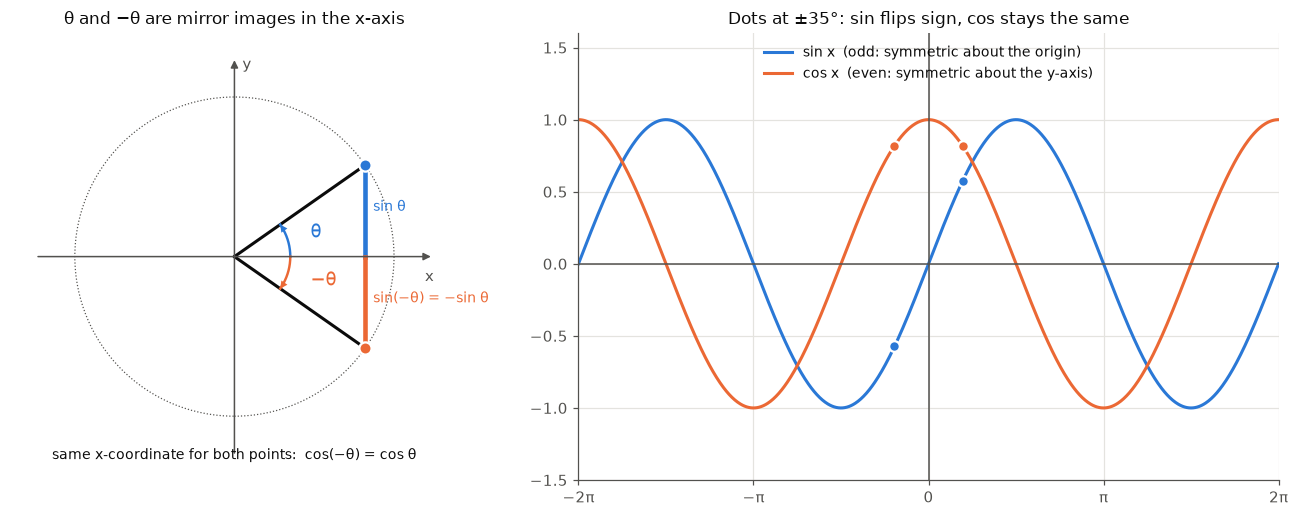

  sin(−θ) = -0.5736,  sin(θ) = +0.5736   →  sin(−θ) = −sin θ
  cos(−θ) = +0.8192,  cos(θ) = +0.8192   →  cos(−θ) = +cos θ
  tan(−θ) = -0.7002,  tan(θ) = +0.7002   →  tan(−θ) = −tan θ
  cot(−θ) = -1.4281,  cot(θ) = +1.4281   →  cot(−θ) = −cot θ
  sec(−θ) = +1.2208,  sec(θ) = +1.2208   →  sec(−θ) = +sec θ
cosec(−θ) = -1.7434,  cosec(θ) = +1.7434   →  cosec(−θ) = −cosec θ


In [5]:
th = np.deg2rad(35)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1, 1.5]})

ax = axes[0]; clean(ax, 1.4); axes_cross(ax, 1.25)
ax.add_patch(Circle((0, 0), 1, fill=False, ec=INK2, lw=0.8, ls=":"))
for ang, col, lab in [(th, BLUE, "θ"), (-th, ORANGE, "−θ")]:
    x, y = np.cos(ang), np.sin(ang)
    ax.plot([0, x], [0, y], color=INK, lw=2)
    ax.plot(x, y, "o", color=col, ms=8, mec="white", mew=1.5, zorder=4)
    ax.plot([x, x], [0, y], color=col, lw=3)
    sweep(ax, 0, np.rad2deg(ang), r0=0.35, color=col)
    ax.text(0.5*np.cos(ang/2), 0.5*np.sin(ang/2), lab, color=col, fontsize=12, ha="left", va="center")
ax.text(np.cos(th) + 0.05, np.sin(th)/2, "sin θ", color=BLUE, fontsize=9)
ax.text(np.cos(th) + 0.05, -np.sin(th)/2, "sin(−θ) = −sin θ", color=ORANGE, fontsize=9)
ax.text(0, -1.2, "same x-coordinate for both points:  cos(−θ) = cos θ", ha="center", va="top", fontsize=9, color=INK)
ax.set_title("θ and −θ are mirror images in the x-axis", fontsize=11)

ax = axes[1]
x = np.linspace(-2*np.pi, 2*np.pi, 1000)
ax.plot(x, np.sin(x), color=BLUE, lw=2, label="sin x  (odd: symmetric about the origin)")
ax.plot(x, np.cos(x), color=ORANGE, lw=2, label="cos x  (even: symmetric about the y-axis)")
ax.axvline(0, color=INK2, lw=1); ax.axhline(0, color=INK2, lw=1)
for v, f, col in [(th, np.sin, BLUE), (th, np.cos, ORANGE)]:
    ax.plot([v, -v], [f(v), f(-v)], "o", color=col, ms=7, mec="white", mew=1.5, zorder=4)
ax.set_xticks(np.arange(-2, 2.01, 1)*np.pi, ["−2π", "−π", "0", "π", "2π"])
ax.set_xlim(-2*np.pi, 2*np.pi); ax.set_ylim(-1.5, 1.6)
ax.legend(frameon=False, loc="upper center", ncol=1, fontsize=9)
ax.set_title("Dots at ±35°: sin flips sign, cos stays the same", fontsize=11)
plt.tight_layout(); plt.show()

for name in F:
    a, b = F[name](-th), F[name](th)
    print(f"{name:>5}(−θ) = {a:+.4f},  {name}(θ) = {b:+.4f}   →  {name}(−θ) = {'+' if np.isclose(a, b) else '−'}{name} θ")

---
## 4. Expansion Formulae

This is the first **new** formula family beyond Class 10. There are 8 formulas in 3 "families". Each family's answer is written in terms of that family:
- $\sin/\cos$ formulas are written in $\sin$ and $\cos$
- $\tan$ formulas are written in $\tan$
- $\cot$ formulas are written in $\cot$

### 4.1 Sine
$$\boxed{\sin(A + B) = \sin A\cos B + \cos A\sin B}$$
$$\boxed{\sin(A - B) = \sin A\cos B - \cos A\sin B}$$
*Same pattern; just change the middle sign.*

### 4.2 Cosine
$$\boxed{\cos(A + B) = \cos A\cos B - \sin A\sin B}$$
$$\boxed{\cos(A - B) = \cos A\cos B + \sin A\sin B}$$
*cos·cos first, then sin·sin. **The sign flips**: $+$ inside gives $-$ outside, and $-$ inside gives $+$ outside.*

> The lecturer will prove these later, in the Complex Numbers chapter, and possibly with vectors or determinants. Here the instruction is to **memorise them right now**. A geometric picture of *why* is in Section 4.5 (an extra, not from the lecture).

### 4.3 Tangent (derived in class)
$$\tan(A+B) = \frac{\sin(A+B)}{\cos(A+B)} = \frac{\sin A\cos B + \cos A\sin B}{\cos A\cos B - \sin A\sin B}$$

**Divide the numerator and denominator by $\cos A\cos B$:**
$$= \frac{\dfrac{\sin A}{\cos A} + \dfrac{\sin B}{\cos B}}{1 - \dfrac{\sin A}{\cos A}\cdot\dfrac{\sin B}{\cos B}}$$

$$\boxed{\tan(A + B) = \frac{\tan A + \tan B}{1 - \tan A\tan B}}, \qquad \boxed{\tan(A - B) = \frac{\tan A - \tan B}{1 + \tan A\tan B}}$$

*Guess $\tan(A-B)$ first: flip both signs.*

### 4.4 Cotangent (derived in class)
$$\cot(A+B) = \frac{\cos(A+B)}{\sin(A+B)} = \frac{\cos A\cos B - \sin A\sin B}{\sin A\cos B + \cos A\sin B}$$

**Divide by $\sin A\sin B$** so that everything becomes $\cot$:
$$\boxed{\cot(A + B) = \frac{\cot A\cot B - 1}{\cot B + \cot A}}, \qquad \boxed{\cot(A - B) = \frac{\cot A\cot B + 1}{\cot B - \cot A}}$$

**Watch out:** the denominator of $\cot(A-B)$ is $\cot B - \cot A$, **not** $\cot A - \cot B$. Students often get this wrong.

### 4.5 Why does $\sin(A+B)$ expand like that? *(extra: geometric picture)*
Build the angle $A + B$ from a unit-length segment in two steps:
1. Walk $\cos B$ along the direction of angle $A$. You reach $(\cos A\cos B,\ \sin A\cos B)$.
2. Turn $90^\circ$ left and walk $\sin B$. That adds $(-\sin A\sin B,\ \cos A\sin B)$.

The endpoint is at distance 1 from $O$, at angle $A + B$. So its coordinates are $(\cos(A+B), \sin(A+B))$. Reading off the totals:
$$\sin(A+B) = \sin A\cos B + \cos A\sin B, \qquad \cos(A+B) = \cos A\cos B - \sin A\sin B$$

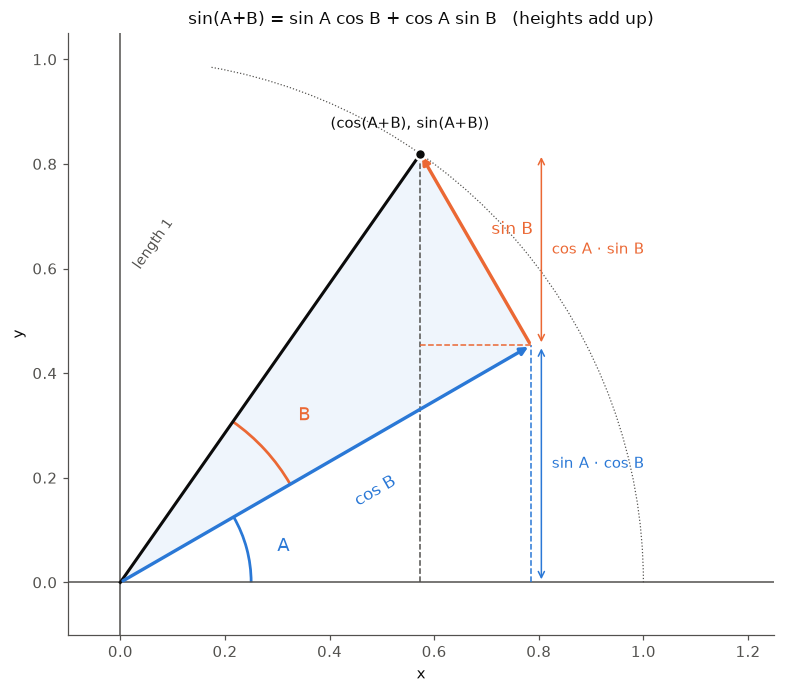

height of endpoint = 0.819152,  sin(A+B) = 0.819152
x of endpoint      = 0.573576,  cos(A+B) = 0.573576


In [6]:
A, B = np.deg2rad(30), np.deg2rad(25)
P1 = np.cos(B)*np.array([np.cos(A), np.sin(A)])
P2 = P1 + np.sin(B)*np.array([-np.sin(A), np.cos(A)])

fig, ax = plt.subplots(figsize=(8, 6.4)); ax.set_aspect("equal"); ax.grid(False)
ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
ax.add_patch(Arc((0, 0), 2, 2, theta1=0, theta2=80, color=INK2, lw=0.8, ls=":"))
ax.add_patch(Polygon([(0, 0), P1, P2], closed=True, fc="#2a78d612", ec="none"))
ax.annotate("", xy=P1, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=2.2))
ax.annotate("", xy=P2, xytext=P1, arrowprops=dict(arrowstyle="-|>", color=ORANGE, lw=2.2))
ax.plot([0, P2[0]], [0, P2[1]], color=INK, lw=2)
ax.plot(*P2, "o", color=INK, ms=7, mec="white", mew=1.5, zorder=5)
# Coordinate breakdown
ax.plot([P1[0], P1[0]], [0, P1[1]], color=BLUE, lw=1, ls="--")
ax.plot([P2[0], P2[0]], [0, P2[1]], color=INK2, lw=1, ls="--")
ax.plot([P2[0], P1[0]], [P1[1], P1[1]], color=ORANGE, lw=1, ls="--")
ax.annotate("", xy=(P1[0] + 0.02, P2[1]), xytext=(P1[0] + 0.02, P1[1]),
            arrowprops=dict(arrowstyle="<->", color=ORANGE, lw=1))
ax.text(P1[0] + 0.04, (P1[1] + P2[1])/2, "cos A · sin B", color=ORANGE, fontsize=10, va="center")
ax.annotate("", xy=(P1[0] + 0.02, P1[1]), xytext=(P1[0] + 0.02, 0),
            arrowprops=dict(arrowstyle="<->", color=BLUE, lw=1))
ax.text(P1[0] + 0.04, P1[1]/2, "sin A · cos B", color=BLUE, fontsize=10, va="center")
ax.text(P1[0]/2 + 0.05, P1[1]/2 - 0.08, "cos B", color=BLUE, fontsize=11, rotation=np.rad2deg(A))
ax.text((P1[0] + P2[0])/2 + 0.03, (P1[1] + P2[1])/2 + 0.03, "sin B", color=ORANGE, fontsize=11, ha="left")
ax.add_patch(Arc((0, 0), 0.5, 0.5, theta1=0, theta2=np.rad2deg(A), color=BLUE, lw=1.8))
ax.add_patch(Arc((0, 0), 0.75, 0.75, theta1=np.rad2deg(A), theta2=np.rad2deg(A + B), color=ORANGE, lw=1.8))
ax.text(0.3, 0.06, "A", color=BLUE, fontsize=12); ax.text(0.34, 0.31, "B", color=ORANGE, fontsize=12)
ax.text(P2[0] - 0.02, P2[1] + 0.05, "(cos(A+B), sin(A+B))", ha="center", fontsize=10)
ax.text(0.02, 0.6, "length 1", fontsize=9, color=INK2, rotation=np.rad2deg(A + B))
ax.set_xlim(-0.1, 1.25); ax.set_ylim(-0.1, 1.05)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("sin(A+B) = sin A cos B + cos A sin B   (heights add up)", fontsize=11)
plt.tight_layout(); plt.show()
print(f"height of endpoint = {P2[1]:.6f},  sin(A+B) = {np.sin(A + B):.6f}")
print(f"x of endpoint      = {P2[0]:.6f},  cos(A+B) = {np.cos(A + B):.6f}")

### 4.6 Common mistake: $\sin(A+B) \neq \sin A + \sin B$
Trig functions are **not** linear. The plot fixes $B = 30^\circ$ and varies $A$.

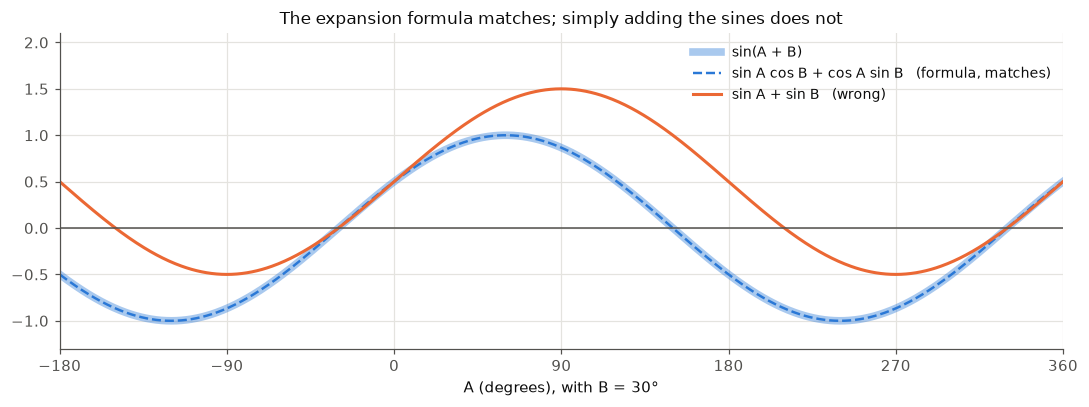

In [7]:
Ad = np.linspace(-180, 360, 800); A = np.deg2rad(Ad); B = np.deg2rad(30)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(Ad, np.sin(A + B), color=BLUE, lw=5, alpha=0.4, label="sin(A + B)")
ax.plot(Ad, np.sin(A)*np.cos(B) + np.cos(A)*np.sin(B), color=BLUE, lw=1.6, ls="--",
        label="sin A cos B + cos A sin B   (formula, matches)")
ax.plot(Ad, np.sin(A) + np.sin(B), color=ORANGE, lw=2, label="sin A + sin B   (wrong)")
ax.axhline(0, color=INK2, lw=1)
ax.set_xticks(range(-180, 361, 90)); ax.set_xlim(-180, 360); ax.set_ylim(-1.3, 2.1)
ax.set_xlabel("A (degrees), with B = 30°")
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.set_title("The expansion formula matches; simply adding the sines does not", fontsize=11)
plt.tight_layout(); plt.show()

In [8]:
# Check all 8 expansion formulae at many random (A, B)
rng = np.random.default_rng(1)
A, B = rng.uniform(-3, 3, 10_000), rng.uniform(-3, 3, 10_000)
sA, cA, sB, cB = np.sin(A), np.cos(A), np.sin(B), np.cos(B)
tA, tB, kA, kB = np.tan(A), np.tan(B), 1/np.tan(A), 1/np.tan(B)
checks = {
    "sin(A+B)": (np.sin(A + B), sA*cB + cA*sB),
    "sin(A−B)": (np.sin(A - B), sA*cB - cA*sB),
    "cos(A+B)": (np.cos(A + B), cA*cB - sA*sB),
    "cos(A−B)": (np.cos(A - B), cA*cB + sA*sB),
    "tan(A+B)": (np.tan(A + B), (tA + tB)/(1 - tA*tB)),
    "tan(A−B)": (np.tan(A - B), (tA - tB)/(1 + tA*tB)),
    "cot(A+B)": (1/np.tan(A + B), (kA*kB - 1)/(kB + kA)),
    "cot(A−B)": (1/np.tan(A - B), (kA*kB + 1)/(kB - kA)),
}
for name, (lhs, rhs) in checks.items():
    ok = np.isclose(lhs, rhs, rtol=1e-6, atol=1e-8)
    print(f"{name}: {ok.mean()*100:6.2f}% of 10,000 random (A, B) pairs agree")

sin(A+B): 100.00% of 10,000 random (A, B) pairs agree
sin(A−B): 100.00% of 10,000 random (A, B) pairs agree
cos(A+B): 100.00% of 10,000 random (A, B) pairs agree
cos(A−B): 100.00% of 10,000 random (A, B) pairs agree
tan(A+B): 100.00% of 10,000 random (A, B) pairs agree
tan(A−B): 100.00% of 10,000 random (A, B) pairs agree
cot(A+B): 100.00% of 10,000 random (A, B) pairs agree
cot(A−B): 100.00% of 10,000 random (A, B) pairs agree


---
## 5. Solved Questions

### Q1. Find $\sin 75^\circ$ (and $\cos 15^\circ$)
$75^\circ$ is not in the table, so write it as a sum of two table angles: $75^\circ = 45^\circ + 30^\circ$.

$$\sin 75^\circ = \sin 45^\circ\cos 30^\circ + \cos 45^\circ\sin 30^\circ = \frac{1}{\sqrt2}\cdot\frac{\sqrt3}{2} + \frac{1}{\sqrt2}\cdot\frac12 = \boxed{\frac{\sqrt3 + 1}{2\sqrt2}}$$

Rationalising differently (multiply the top and bottom by $\sqrt3 - 1$):
$$\frac{\sqrt3+1}{2\sqrt2}\cdot\frac{\sqrt3-1}{\sqrt3-1} = \frac{3 - 1}{2\sqrt2(\sqrt3 - 1)} = \frac{1}{\sqrt6 - \sqrt2}$$

**Bonus:** $\sin 75^\circ = \sin(90^\circ - 15^\circ) = \cos 15^\circ$. JEE aspirants often memorise this value.

In [9]:
v = np.sin(np.deg2rad(75))
print(f"sin 75°            = {v:.6f}")
print(f"(√3 + 1)/(2√2)     = {(np.sqrt(3) + 1)/(2*np.sqrt(2)):.6f}")
print(f"1/(√6 − √2)        = {1/(np.sqrt(6) - np.sqrt(2)):.6f}")
print(f"cos 15°            = {np.cos(np.deg2rad(15)):.6f}")

sin 75°            = 0.965926
(√3 + 1)/(2√2)     = 0.965926
1/(√6 − √2)        = 0.965926
cos 15°            = 0.965926


### Q2. If $\sin A = \frac35$ and $\cos B = \frac{9}{41}$ (both angles in quadrant I), find $\sin(A - B)$.

$$\sin(A - B) = \sin A\cos B - \cos A\sin B$$

We need $\cos A$ and $\sin B$. Both are positive because both angles are in quadrant I:
$$\cos A = \sqrt{1 - \sin^2 A} = \sqrt{1 - \tfrac{9}{25}} = \tfrac45$$
$$\sin B = \sqrt{1 - \cos^2 B} = \sqrt{1 - \tfrac{81}{1681}} = \sqrt{\tfrac{1600}{1681}} = \tfrac{40}{41}$$

Substituting:
$$\sin(A - B) = \frac35\cdot\frac{9}{41} - \frac45\cdot\frac{40}{41} = \frac{27 - 160}{205} = \boxed{-\frac{133}{205}}$$

The answer is negative because $B > A$ here, so $A - B$ is a negative angle (see the triangles below).

> **Homework from the lecture:** find $\cos(A + B)$ with the same data.

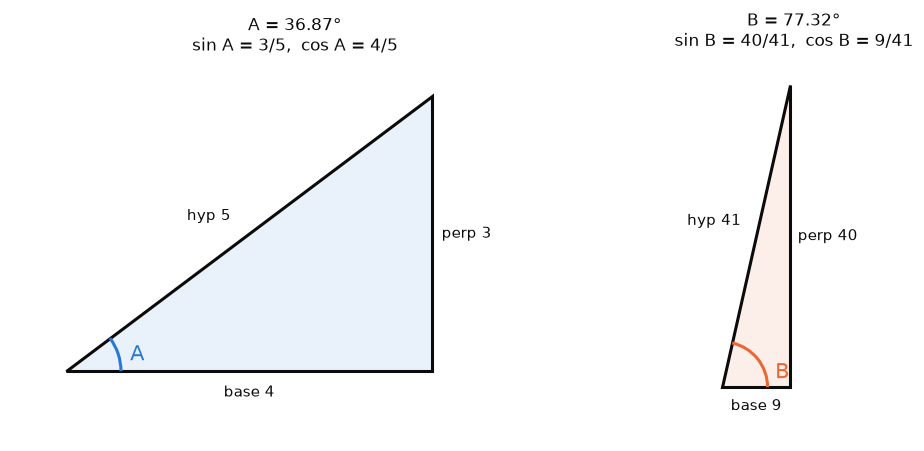

sin(A − B) = -0.648780   −133/205 = -0.648780


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (base, perp, hyp, name, col) in zip(axes, [(4, 3, 5, "A", BLUE), (9, 40, 41, "B", ORANGE)]):
    ax.set_aspect("equal"); ax.axis("off")
    s = 4/max(base, perp)
    pts = np.array([(0, 0), (base*s, 0), (base*s, perp*s)])
    ax.add_patch(Polygon(pts, closed=True, fc=col + "1a", ec=INK, lw=2))
    ax.add_patch(Arc((0, 0), 1.2, 1.2, theta1=0, theta2=np.rad2deg(np.arctan2(perp, base)), color=col, lw=2))
    ax.text(0.7, 0.12, name, color=col, fontsize=14)
    ax.text(base*s/2, -0.15, f"base {base}", ha="center", va="top")
    ax.text(base*s + 0.1, perp*s/2, f"perp {perp}", va="center")
    ax.text(base*s/2 - 0.2, perp*s/2 + 0.15, f"hyp {hyp}", ha="right")
    ax.set_xlim(-0.6, base*s + 1.6); ax.set_ylim(-0.7, perp*s + 0.4)
    trig = f"sin {name} = {perp}/{hyp},  cos {name} = {base}/{hyp}"
    ax.set_title(f"{name} = {np.rad2deg(np.arctan2(perp, base)):.2f}°\n{trig}", fontsize=11)
plt.tight_layout(); plt.show()

A, B = np.arcsin(3/5), np.arccos(9/41)
print(f"sin(A − B) = {np.sin(A - B):.6f}   −133/205 = {-133/205:.6f}")

<details>
<summary>Homework answer: cos(A + B) (open after attempting)</summary>

$$\cos(A+B) = \cos A\cos B - \sin A\sin B = \frac45\cdot\frac{9}{41} - \frac35\cdot\frac{40}{41} = \frac{36 - 120}{205} = -\frac{84}{205}$$
</details>

In [11]:
print(f"cos(A + B) = {np.cos(A + B):.6f}   −84/205 = {-84/205:.6f}")

cos(A + B) = -0.409756   −84/205 = -0.409756


---
## 6. Summary

**Axis angles:** $n\pi$ lie on the x-axis (function unchanged). $(2n+1)\frac{\pi}{2}$ lie on the y-axis (sin↔cos, tan↔cot, sec↔cosec). The sign always comes from the quadrant of the original function.

**Negative angles:** $\cos(-\theta) = \cos\theta$ and $\sec(-\theta) = \sec\theta$. The other four functions pull the minus sign out.

**The 8 expansion formulae:**

| | $A + B$ | $A - B$ |
|---|---|---|
| $\sin$ | $\sin A\cos B + \cos A\sin B$ | $\sin A\cos B - \cos A\sin B$ |
| $\cos$ | $\cos A\cos B - \sin A\sin B$ | $\cos A\cos B + \sin A\sin B$ |
| $\tan$ | $\dfrac{\tan A + \tan B}{1 - \tan A\tan B}$ | $\dfrac{\tan A - \tan B}{1 + \tan A\tan B}$ |
| $\cot$ | $\dfrac{\cot A\cot B - 1}{\cot B + \cot A}$ | $\dfrac{\cot A\cot B + 1}{\cot B - \cot A}$ |

**Technique:** to find a ratio of a "non-standard" angle, split it into standard angles ($75^\circ = 45^\circ + 30^\circ$, $15^\circ = 45^\circ - 30^\circ$, …) and expand.

### Practice
1. $\cos 75^\circ$, $\tan 75^\circ$, $\tan 15^\circ$, $\sin 105^\circ$
2. $\sin\left(\frac{7\pi}{2} - \theta\right)$, $\sec(5\pi + \theta)$, $\csc\left(-\frac{\pi}{2} - \theta\right)$
3. Prove $\tan(A - B)$ from $\sin(A - B)$ and $\cos(A - B)$ yourself.
4. Using the Q2 data, find $\tan(A + B)$ in two ways: from the tan formula, and as $\sin(A+B)/\cos(A+B)$.

In [12]:
# Answers to practice questions 1 and 2 (check after attempting)
d = np.deg2rad
print("1.", f"cos75° = {np.cos(d(75)):.6f} (= (√3−1)/(2√2) = {(np.sqrt(3)-1)/(2*np.sqrt(2)):.6f})")
print("  ", f"tan75° = {np.tan(d(75)):.6f} (= 2+√3),  tan15° = {np.tan(d(15)):.6f} (= 2−√3),  sin105° = {np.sin(d(105)):.6f}")
for f, k, sgn, lab in [("sin", 7, -1, "sin(7π/2 − θ)"), ("sec", 10, 1, "sec(5π + θ)"), ("cosec", -1, -1, "cosec(−π/2 − θ)")]:
    s, g, q = allied(f, k, sgn)
    print("2." if lab.startswith("sin") else "  ", f"{lab} = {s}{g} θ")

1. cos75° = 0.258819 (= (√3−1)/(2√2) = 0.258819)
   tan75° = 3.732051 (= 2+√3),  tan15° = 0.267949 (= 2−√3),  sin105° = 0.965926
2. sin(7π/2 − θ) = −cos θ
   sec(5π + θ) = −sec θ
   cosec(−π/2 − θ) = −sec θ
